In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    roc_auc_score, f1_score
)
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

# Import feature engineering pipeline -- LKT
from pipeline.ingestion.feature_engineering import prepare_train_test

# Load and prepare data using our production module
df = pd.read_csv('data/raw/creditcard.csv')
X_train, X_test, y_train, y_test = prepare_train_test(df)

print(f"Training: {X_train.shape[0]:,} transactions, {y_train.sum():.0f} frauds")
print(f"Test: {X_test.shape[0]:,} transactions, {y_test.sum():.0f} frauds")
print(f"Features: {X_train.shape[1]}")
print(f"\nUsing production feature engineering module ✓")

Training: 227,845 transactions, 417 frauds
Test: 56,962 transactions, 75 frauds
Features: 40

Using production feature engineering module ✓


In [2]:
# Set up MLflow experiment
mlflow.set_experiment("fraud-detection")

# EXPERIMENT 1: Baseline XGBoost with class weights
# scale_pos_weight handles the imbalance — tells the model
# "fraud samples are 577x more important than legitimate ones"
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

with mlflow.start_run(run_name="baseline_xgboost"):
    
    # Define hyperparameters
    params = {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "scale_pos_weight": scale,
        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1  # use all CPU cores
    }
    
    # Log parameters to MLflow
    mlflow.log_params(params)
    
    # Train the model
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of fraud
    
    # Calculate metrics
    auc_pr = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    
    # Log metrics to MLflow
    mlflow.log_metrics({
        "auc_pr": auc_pr,
        "roc_auc": roc_auc,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })
    
    # Log the model
    mlflow.xgboost.log_model(model, "model")
    
    # Print results
    print("=" * 50)
    print("EXPERIMENT 1: Baseline XGBoost")
    print("=" * 50)
    print(f"\nAUC-PR:     {auc_pr:.4f}")
    print(f"ROC-AUC:    {roc_auc:.4f}")
    print(f"F1 Score:   {f1:.4f}")
    print(f"Precision:  {precision:.4f}  (of flagged transactions, {precision*100:.1f}% were actually fraud)")
    print(f"Recall:     {recall:.4f}  (caught {recall*100:.1f}% of all frauds)")
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn:,}  (legitimate, correctly cleared)")
    print(f"  False Positives: {fp:,}  (legitimate, wrongly flagged)")
    print(f"  False Negatives: {fn:,}  (fraud, MISSED)")
    print(f"  True Positives:  {tp:,}  (fraud, CAUGHT)")
    print(f"\nMLflow run logged ✓")

2026/03/07 11:30:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/07 11:30:49 INFO mlflow.store.db.utils: Updating database tables
2026/03/07 11:30:49 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection' does not exist. Creating a new experiment.
2026/03/07 11:30:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


EXPERIMENT 1: Baseline XGBoost

AUC-PR:     0.7734
ROC-AUC:    0.9829
F1 Score:   0.7808
Precision:  0.8028  (of flagged transactions, 80.3% were actually fraud)
Recall:     0.7600  (caught 76.0% of all frauds)

Confusion Matrix:
  True Negatives:  56,873  (legitimate, correctly cleared)
  False Positives: 14  (legitimate, wrongly flagged)
  False Negatives: 18  (fraud, MISSED)
  True Positives:  57  (fraud, CAUGHT)

MLflow run logged ✓


In [3]:
# EXPERIMENT 2: More trees, deeper learning
with mlflow.start_run(run_name="deeper_xgboost"):
    
    params2 = {
        "n_estimators": 300,
        "max_depth": 8,
        "learning_rate": 0.05,
        "scale_pos_weight": scale,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1
    }
    
    mlflow.log_params(params2)
    
    model2 = xgb.XGBClassifier(**params2)
    model2.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    y_pred2 = model2.predict(X_test)
    y_prob2 = model2.predict_proba(X_test)[:, 1]
    
    auc_pr2 = average_precision_score(y_test, y_prob2)
    roc_auc2 = roc_auc_score(y_test, y_prob2)
    f1_2 = f1_score(y_test, y_pred2)
    cm2 = confusion_matrix(y_test, y_pred2)
    tn2, fp2, fn2, tp2 = cm2.ravel()
    precision2 = tp2 / (tp2 + fp2)
    recall2 = tp2 / (tp2 + fn2)
    
    mlflow.log_metrics({
        "auc_pr": auc_pr2, "roc_auc": roc_auc2, "f1_score": f1_2,
        "precision": precision2, "recall": recall2,
        "true_positives": tp2, "false_positives": fp2,
        "false_negatives": fn2, "true_negatives": tn2
    })
    mlflow.xgboost.log_model(model2, "model")
    
    print("=" * 50)
    print("EXPERIMENT 2: Deeper XGBoost (300 trees, depth 8)")
    print("=" * 50)
    print(f"AUC-PR:     {auc_pr2:.4f}")
    print(f"Precision:  {precision2:.4f}")
    print(f"Recall:     {recall2:.4f}")
    print(f"Missed frauds: {fn2}  |  False alarms: {fp2}")


# EXPERIMENT 3: Aggressive fraud catching (higher scale_pos_weight)
with mlflow.start_run(run_name="aggressive_recall"):
    
    params3 = {
        "n_estimators": 200,
        "max_depth": 7,
        "learning_rate": 0.05,
        "scale_pos_weight": scale * 2,  # Double the fraud importance
        "min_child_weight": 2,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1
    }
    
    mlflow.log_params(params3)
    
    model3 = xgb.XGBClassifier(**params3)
    model3.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    y_pred3 = model3.predict(X_test)
    y_prob3 = model3.predict_proba(X_test)[:, 1]
    
    auc_pr3 = average_precision_score(y_test, y_prob3)
    roc_auc3 = roc_auc_score(y_test, y_prob3)
    f1_3 = f1_score(y_test, y_pred3)
    cm3 = confusion_matrix(y_test, y_pred3)
    tn3, fp3, fn3, tp3 = cm3.ravel()
    precision3 = tp3 / (tp3 + fp3)
    recall3 = tp3 / (tp3 + fn3)
    
    mlflow.log_metrics({
        "auc_pr": auc_pr3, "roc_auc": roc_auc3, "f1_score": f1_3,
        "precision": precision3, "recall": recall3,
        "true_positives": tp3, "false_positives": fp3,
        "false_negatives": fn3, "true_negatives": tn3
    })
    mlflow.xgboost.log_model(model3, "model")
    
    print(f"\n{'=' * 50}")
    print("EXPERIMENT 3: Aggressive Recall (2x fraud weight)")
    print("=" * 50)
    print(f"AUC-PR:     {auc_pr3:.4f}")
    print(f"Precision:  {precision3:.4f}")
    print(f"Recall:     {recall3:.4f}")
    print(f"Missed frauds: {fn3}  |  False alarms: {fp3}")

# COMPARISON
print(f"\n{'=' * 50}")
print("EXPERIMENT COMPARISON")
print("=" * 50)
print(f"{'Metric':<20} {'Baseline':<12} {'Deeper':<12} {'Aggressive':<12}")
print(f"{'-'*56}")
print(f"{'AUC-PR':<20} {auc_pr:<12.4f} {auc_pr2:<12.4f} {auc_pr3:<12.4f}")
print(f"{'Precision':<20} {precision:<12.4f} {precision2:<12.4f} {precision3:<12.4f}")
print(f"{'Recall':<20} {recall:<12.4f} {recall2:<12.4f} {recall3:<12.4f}")
print(f"{'Missed Frauds':<20} {fn:<12} {fn2:<12} {fn3:<12}")
print(f"{'False Alarms':<20} {fp:<12} {fp2:<12} {fp3:<12}")
print(f"\nAll 3 experiments tracked in MLflow ✓")

2026/03/07 11:33:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


EXPERIMENT 2: Deeper XGBoost (300 trees, depth 8)
AUC-PR:     0.8040
Precision:  0.8769
Recall:     0.7600
Missed frauds: 18  |  False alarms: 8


2026/03/07 11:33:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



EXPERIMENT 3: Aggressive Recall (2x fraud weight)
AUC-PR:     0.7922
Precision:  0.8507
Recall:     0.7600
Missed frauds: 18  |  False alarms: 10

EXPERIMENT COMPARISON
Metric               Baseline     Deeper       Aggressive  
--------------------------------------------------------
AUC-PR               0.7734       0.8040       0.7922      
Precision            0.8028       0.8769       0.8507      
Recall               0.7600       0.7600       0.7600      
Missed Frauds        18           18           18          
False Alarms         14           8            10          

All 3 experiments tracked in MLflow ✓


THRESHOLD ANALYSIS (Deeper XGBoost)
Threshold    Precision    Recall       Caught     Missed     False Alarms
----------------------------------------------------------------------
0.3          0.8507       0.7600       57         18         10
0.4          0.8636       0.7600       57         18         9
0.5          0.8769       0.7600       57         18         8
0.6          0.8769       0.7600       57         18         8
0.7          0.8906       0.7600       57         18         7
0.8          0.8906       0.7600       57         18         7


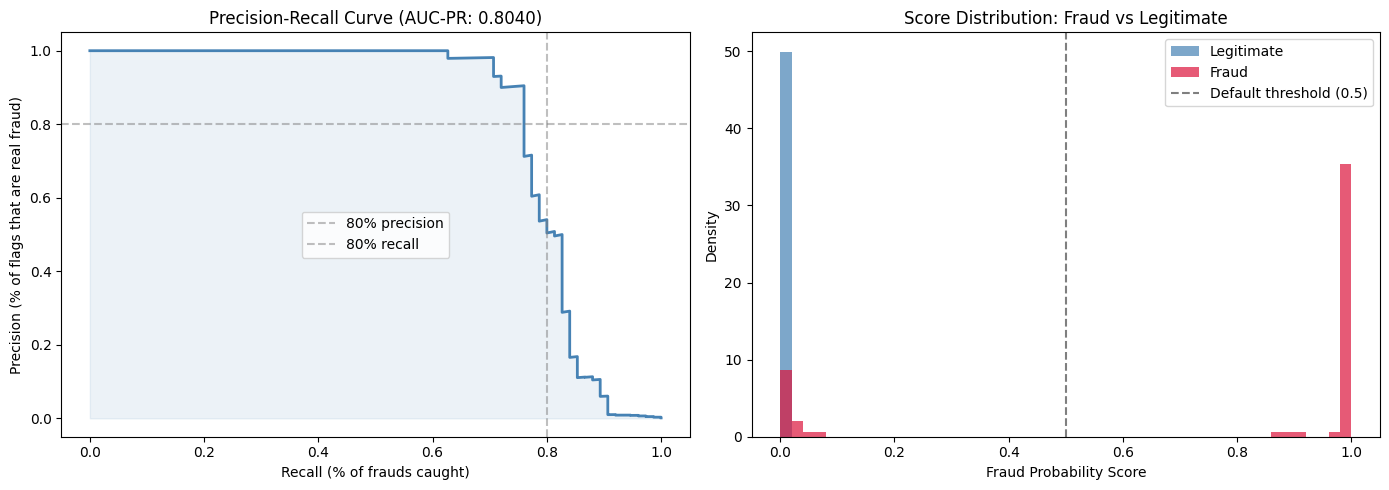


Key insight: Lowering the threshold catches more fraud but flags more legitimate transactions.
In production, the business decides the threshold — how many false alarms are acceptable
to catch one more fraud? That's a business decision, not a technical one.


In [4]:
# THRESHOLD ANALYSIS — this is what fraud teams actually do in production
# Using the best model (Experiment 2: Deeper XGBoost)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("THRESHOLD ANALYSIS (Deeper XGBoost)")
print("=" * 70)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'Caught':<10} {'Missed':<10} {'False Alarms'}")
print("-" * 70)

for t in thresholds:
    y_pred_t = (y_prob2 >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    rec_t = tp_t / (tp_t + fn_t)
    print(f"{t:<12.1f} {prec_t:<12.4f} {rec_t:<12.4f} {tp_t:<10} {fn_t:<10} {fp_t}")

# Visualize the precision-recall tradeoff
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_test, y_prob2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
axes[0].plot(rec_curve, prec_curve, color='steelblue', linewidth=2)
axes[0].fill_between(rec_curve, prec_curve, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Recall (% of frauds caught)')
axes[0].set_ylabel('Precision (% of flags that are real fraud)')
axes[0].set_title(f'Precision-Recall Curve (AUC-PR: {auc_pr2:.4f})')
axes[0].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80% precision')
axes[0].axvline(x=0.8, color='gray', linestyle='--', alpha=0.5, label='80% recall')
axes[0].legend()

# Score distribution — how the model separates fraud from legitimate
axes[1].hist(y_prob2[y_test==0], bins=50, alpha=0.7, label='Legitimate', color='steelblue', density=True)
axes[1].hist(y_prob2[y_test==1], bins=50, alpha=0.7, label='Fraud', color='crimson', density=True)
axes[1].set_xlabel('Fraud Probability Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution: Fraud vs Legitimate')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nKey insight: Lowering the threshold catches more fraud but flags more legitimate transactions.")
print(f"In production, the business decides the threshold — how many false alarms are acceptable")
print(f"to catch one more fraud? That's a business decision, not a technical one.")

In [5]:
# Let's see what MLflow tracked
experiment = mlflow.get_experiment_by_name("fraud-detection")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

print("MLflow EXPERIMENT TRACKER")
print("=" * 70)
print(f"\nExperiment: {experiment.name}")
print(f"Total runs: {len(runs)}")
print(f"\nAll runs:")
print(runs[['tags.mlflow.runName', 'metrics.auc_pr', 'metrics.precision', 
            'metrics.recall', 'metrics.false_positives', 'metrics.false_negatives']].to_string(index=False))

print(f"\nBest model by AUC-PR: {runs.loc[runs['metrics.auc_pr'].idxmax(), 'tags.mlflow.runName']}")
print(f"\nMLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"\nTo see the full MLflow dashboard, run in terminal:")
print(f"  cd ~/Developer/enterprise-mlops-platform && mlflow ui")
print(f"  Then open http://localhost:5000")

MLflow EXPERIMENT TRACKER

Experiment: fraud-detection
Total runs: 3

All runs:
tags.mlflow.runName  metrics.auc_pr  metrics.precision  metrics.recall  metrics.false_positives  metrics.false_negatives
  aggressive_recall        0.792202           0.850746            0.76                     10.0                     18.0
     deeper_xgboost        0.803990           0.876923            0.76                      8.0                     18.0
   baseline_xgboost        0.773439           0.802817            0.76                     14.0                     18.0

Best model by AUC-PR: deeper_xgboost

MLflow tracking URI: sqlite:////Users/ltiwari/Developer/enterprise-mlops-platform/mlflow.db

To see the full MLflow dashboard, run in terminal:
  cd ~/Developer/enterprise-mlops-platform && mlflow ui
  Then open http://localhost:5000


In [6]:
%%writefile pipeline/training/train_model.py
"""
Model Training Pipeline for Fraud Detection
Enterprise MLOps Platform

Trains XGBoost classifier with MLflow experiment tracking.
Every training run is logged: parameters, metrics, model artifacts.
"""

import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, confusion_matrix
)
import sys
sys.path.insert(0, '.')
from pipeline.ingestion.feature_engineering import prepare_train_test


def train_fraud_model(
    data_path: str = "data/raw/creditcard.csv",
    experiment_name: str = "fraud-detection",
    run_name: str = "default_run",
    params: dict = None
):
    """
    Train a fraud detection model with full MLflow tracking.
    
    Args:
        data_path: Path to raw transaction data
        experiment_name: MLflow experiment name
        run_name: Name for this training run
        params: XGBoost hyperparameters (uses defaults if None)
    
    Returns:
        dict with model, metrics, and MLflow run_id
    """
    # Load and prepare data using production feature engineering
    df = pd.read_csv(data_path)
    X_train, X_test, y_train, y_test = prepare_train_test(df)
    
    # Calculate class weight for imbalanced data
    scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
    
    # Default parameters — our best performing config
    if params is None:
        params = {
            "n_estimators": 300,
            "max_depth": 8,
            "learning_rate": 0.05,
            "scale_pos_weight": scale,
            "min_child_weight": 3,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "eval_metric": "aucpr",
            "random_state": 42,
            "n_jobs": -1
        }
    
    # Train with MLflow tracking
    mlflow.set_experiment(experiment_name)
    
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        
        # Evaluate
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        auc_pr = average_precision_score(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn)
        
        metrics = {
            "auc_pr": auc_pr,
            "roc_auc": roc_auc,
            "f1_score": f1,
            "precision": precision,
            "recall": recall,
            "true_positives": tp,
            "false_positives": fp,
            "false_negatives": fn,
            "true_negatives": tn
        }
        
        mlflow.log_metrics(metrics)
        mlflow.xgboost.log_model(model, "model")
        
        print(f"Run: {run_name}")
        print(f"AUC-PR: {auc_pr:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
        print(f"Caught: {tp} | Missed: {fn} | False alarms: {fp}")
        print(f"MLflow run ID: {run.info.run_id}")
        
        return {
            "model": model,
            "metrics": metrics,
            "run_id": run.info.run_id,
            "X_test": X_test,
            "y_test": y_test,
            "y_prob": y_prob
        }


if __name__ == "__main__":
    result = train_fraud_model(run_name="production_candidate")
    print(f"\nModel trained and tracked successfully.")
    print(f"View at: mlflow ui --port 5001")

Writing pipeline/training/train_model.py
